            Recency  Frequency     Monetary
Cluster                                    
0         72.741611   8.516779  3322.222985
1        101.197015   4.731343  1669.688290
2        123.718750   8.296875  9479.545687
3        559.489583   3.697917  1470.228226


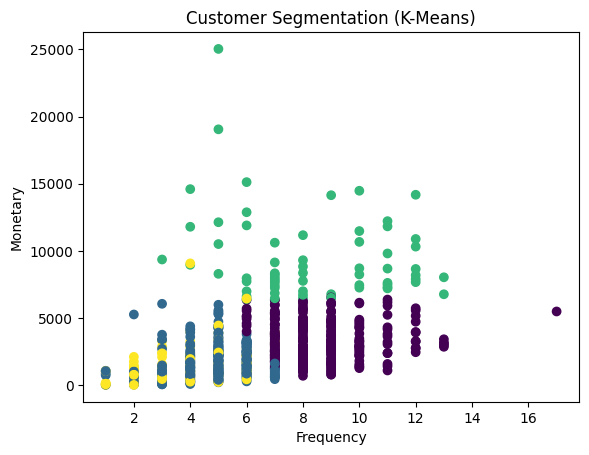

In [ ]:
# Customer Segmentation using K-Means Clustering

import pandas as pd
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("/content/Sample - Superstore.xls")
df['Order Date'] = pd.to_datetime(df['Order Date'])

# RFM calculation
current_date = df['Order Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (current_date - x.max()).days,  # Recency
    'Order ID': 'nunique',  # Frequency
    'Sales': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Normalize data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Analyze cluster means
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_summary)

# Visualize clusters
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segmentation (K-Means)')
plt.show()


/tmp/ipython-input-1488493940.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp80imvtw7/1wul8bdp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp80imvtw7/d2ed2zq2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61365', 'data', 'file=/tmp/tmp80imvtw7/1wul8bdp.json', 'init=/tmp/tmp80imvtw7/d2ed2zq2.json', 'output', 'file=/tmp/tmp80imvtw7/prophet_model5xq76_j6/prophet_model-20251009085755.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
0

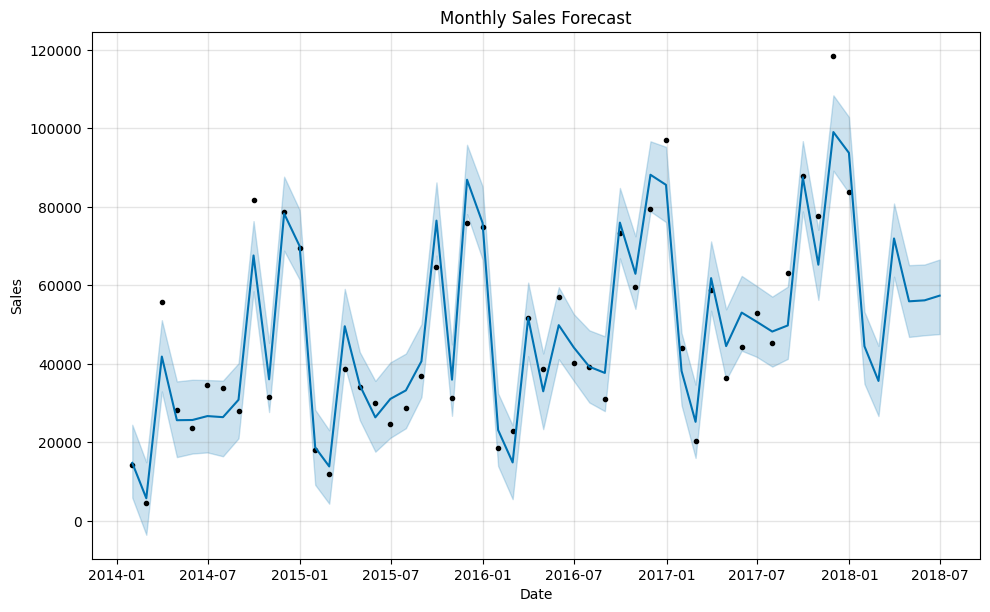

           ds          yhat    yhat_lower    yhat_upper
48 2018-01-31  44491.106116  34948.463031  53266.150996
49 2018-02-28  35661.339215  26718.707742  44587.660257
50 2018-03-31  71959.875153  62213.863370  80859.402837
51 2018-04-30  55942.099958  46868.511465  65152.369484
52 2018-05-31  56193.090518  47299.850858  65322.024640
53 2018-06-30  57388.058092  47594.291799  66586.992172


In [ ]:
# Demand Forecasting using Prophet

import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("/content/Sample - Superstore.xls")

# Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Prepare monthly sales data
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()
monthly_sales.columns = ['ds', 'y']  # Prophet requires columns ds (date) and y (value)

# Initialize and fit model
model = Prophet()
model.fit(monthly_sales)

# Create future dataframe (next 6 months)
future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)
plt.title("Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Optional: Display forecasted values
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))


In [1]:
# Profitability Prediction using Logistic Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Load data
df = pd.read_excel("Sample - Superstore.xls")

# Prepare target (Profit > 0 => 1, else 0)
df['ProfitFlag'] = df['Profit'].apply(lambda x: 1 if x > 0 else 0)

# Select features
features = ['Sales', 'Quantity', 'Discount', 'Category', 'Region', 'Segment']
df = df[features + ['ProfitFlag']]

# Encode categorical variables
le = LabelEncoder()
for col in ['Category', 'Region', 'Segment']:
    df[col] = le.fit_transform(df[col])

X = df.drop('ProfitFlag', axis=1)
y = df['ProfitFlag']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


FileNotFoundError: [Errno 2] No such file or directory: 'Sample - Superstore.xls'

In [2]:
# Sales Prediction using Random Forest

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_excel("/content/Sample - Superstore.xls")

# Select relevant features
features = ['Quantity', 'Discount', 'Profit', 'Category', 'Region', 'Segment']
target = 'Sales'

# Encode categorical columns
le = LabelEncoder()
for col in ['Category', 'Region', 'Segment']:
    df[col] = le.fit_transform(df[col])

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


FileNotFoundError: [Errno 2] No such file or directory: '/content/Sample - Superstore.xls'